<a href="https://colab.research.google.com/github/marwanhaggag56/JOBS-ALL-OVER-THE-WORLD/blob/main/Predict_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder



LOAD DATA

In [ ]:
df = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
sample_sub = pd.read_csv('/content/sample_submission.csv')

print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (594194, 21), Test shape: (254655, 20)


In [ ]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

STATISTICS

In [ ]:
df.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


TRANSFORM PIPELINE FOR NULLS

In [ ]:
for col in df.columns:

    if df[col].dtype == "object" or df[col].nunique() < 10:
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        skewness = df[col].skew()

        if abs(skewness) > 1:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)

WHAT DOES THIS PIPELINE DO ?
| Condition        | Action |
| ---------------- | ------ |
| categorical      | mode   |
| numeric + skewed | median |
| numeric + normal | mean   |



In [ ]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-1yr","1-2yr","2-4yr","4-6yr"]
)

In [ ]:
df["avg_spend"] = df["TotalCharges"] / (df["tenure"] + 1)

In [ ]:
df.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.579457
                Yes      0.420543
One year        No       0.942372
                Yes      0.057628
Two year        No       0.990018
                Yes      0.009982
Name: proportion, dtype: float64

In [ ]:
df.groupby("tenure_group")["Churn"].value_counts(normalize=True)

tenure_group  Churn
0-1yr         No       0.506053
              Yes      0.493947
1-2yr         No       0.714219
              Yes      0.285781
2-4yr         No       0.829343
              Yes      0.170657
4-6yr         No       0.947296
              Yes      0.052704
Name: proportion, dtype: float64

In [ ]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.579457,0.420543
One year,0.942372,0.057628
Two year,0.990018,0.009982


MONTH TO MONTH HAS THE MOST CHURN.

In [ ]:
pd.crosstab(df["tenure_group"], df["Churn"], normalize="index")

Churn,No,Yes
tenure_group,,
0-1yr,0.506053,0.493947
1-2yr,0.714219,0.285781
2-4yr,0.829343,0.170657
4-6yr,0.947296,0.052704


NON TENURE CUSTOMERS TEND TO CHURN THE MOST

In [ ]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index")

Churn,No,Yes
SeniorCitizen,,
0,0.810226,0.189774
1,0.499683,0.500317


VISUALIZATION

<Axes: xlabel='Contract', ylabel='count'>

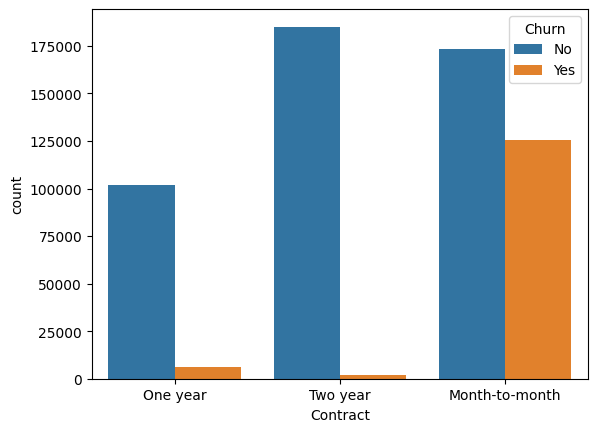

In [ ]:
import seaborn as sns

sns.countplot(data=df, x="Contract", hue="Churn")

<Axes: xlabel='tenure_group', ylabel='count'>

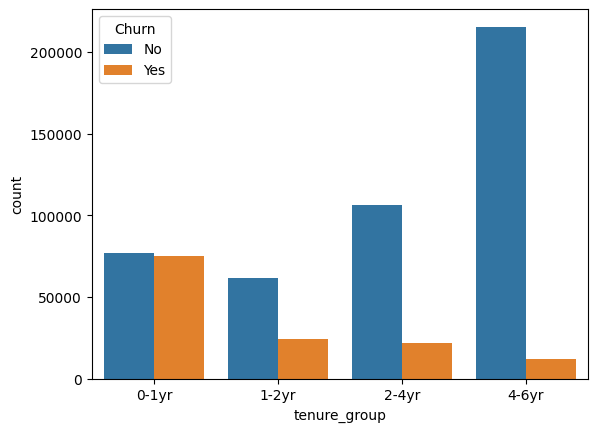

In [ ]:
sns.countplot(data=df, x="tenure_group", hue="Churn")

<Axes: xlabel='SeniorCitizen', ylabel='count'>

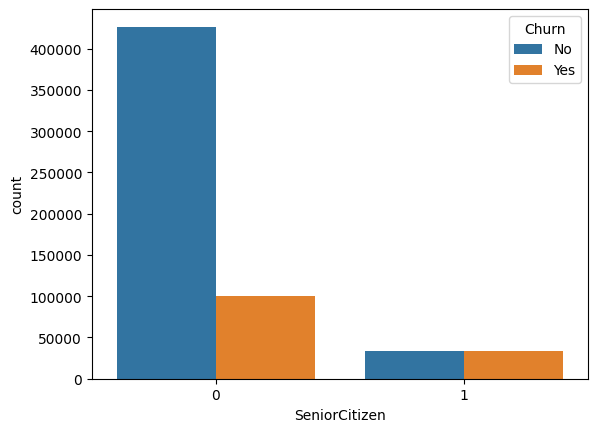

In [ ]:
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

In [ ]:
df.to_csv("clean_churn_data.csv", index=False)